# Algothon 2026 — Instrument Data Visualisation

Exploratory visual analysis of all 51 instruments in `prices.txt`.

**Note on packages:** local notebook exploration has *no* package restriction — the
accepted-package list only applies to `teamName.py` at grading time. This notebook uses
only `numpy`, `pandas`, `matplotlib` so it runs anywhere; optional `ipywidgets` cell at
the end adds an interactive selector if you have it.

Sections: setup · price paths · returns & volatility · cross-sectional structure ·
per-instrument dashboard · interactive explorer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

# ---- load ----
df = pd.read_csv("prices.txt", sep=r"\s+")     # columns = tickers, rows = days
P  = df                                          # price DataFrame (days x 51)
tickers = list(df.columns)
days = np.arange(len(df))

# log returns (additive, symmetric) -> the basis for almost everything
R = np.log(P / P.shift(1)).dropna()              # (days-1 x 51) DataFrame
Rv = R.values
algo = R["ALGO"]                                 # instrument 0 == market proxy

print(f"{P.shape[1]} instruments, {P.shape[0]} days")
P.head()

51 instruments, 500 days


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


## 1. Price paths

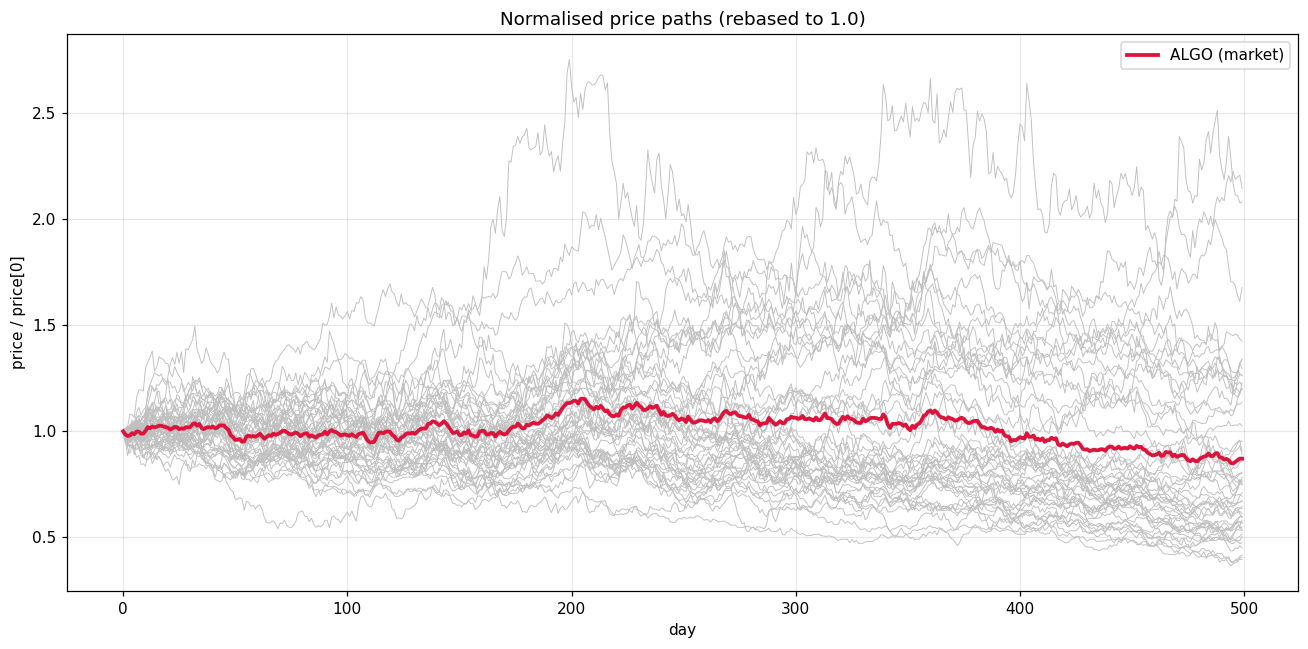

In [2]:
# All instruments rebased to 1.0, ALGO highlighted as the market
norm = P / P.iloc[0]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(norm.drop(columns="ALGO"), color="0.75", lw=0.6)
ax.plot(norm["ALGO"], color="crimson", lw=2.5, label="ALGO (market)")
ax.set(title="Normalised price paths (rebased to 1.0)", xlabel="day", ylabel="price / price[0]")
ax.legend(); plt.tight_layout(); plt.show()

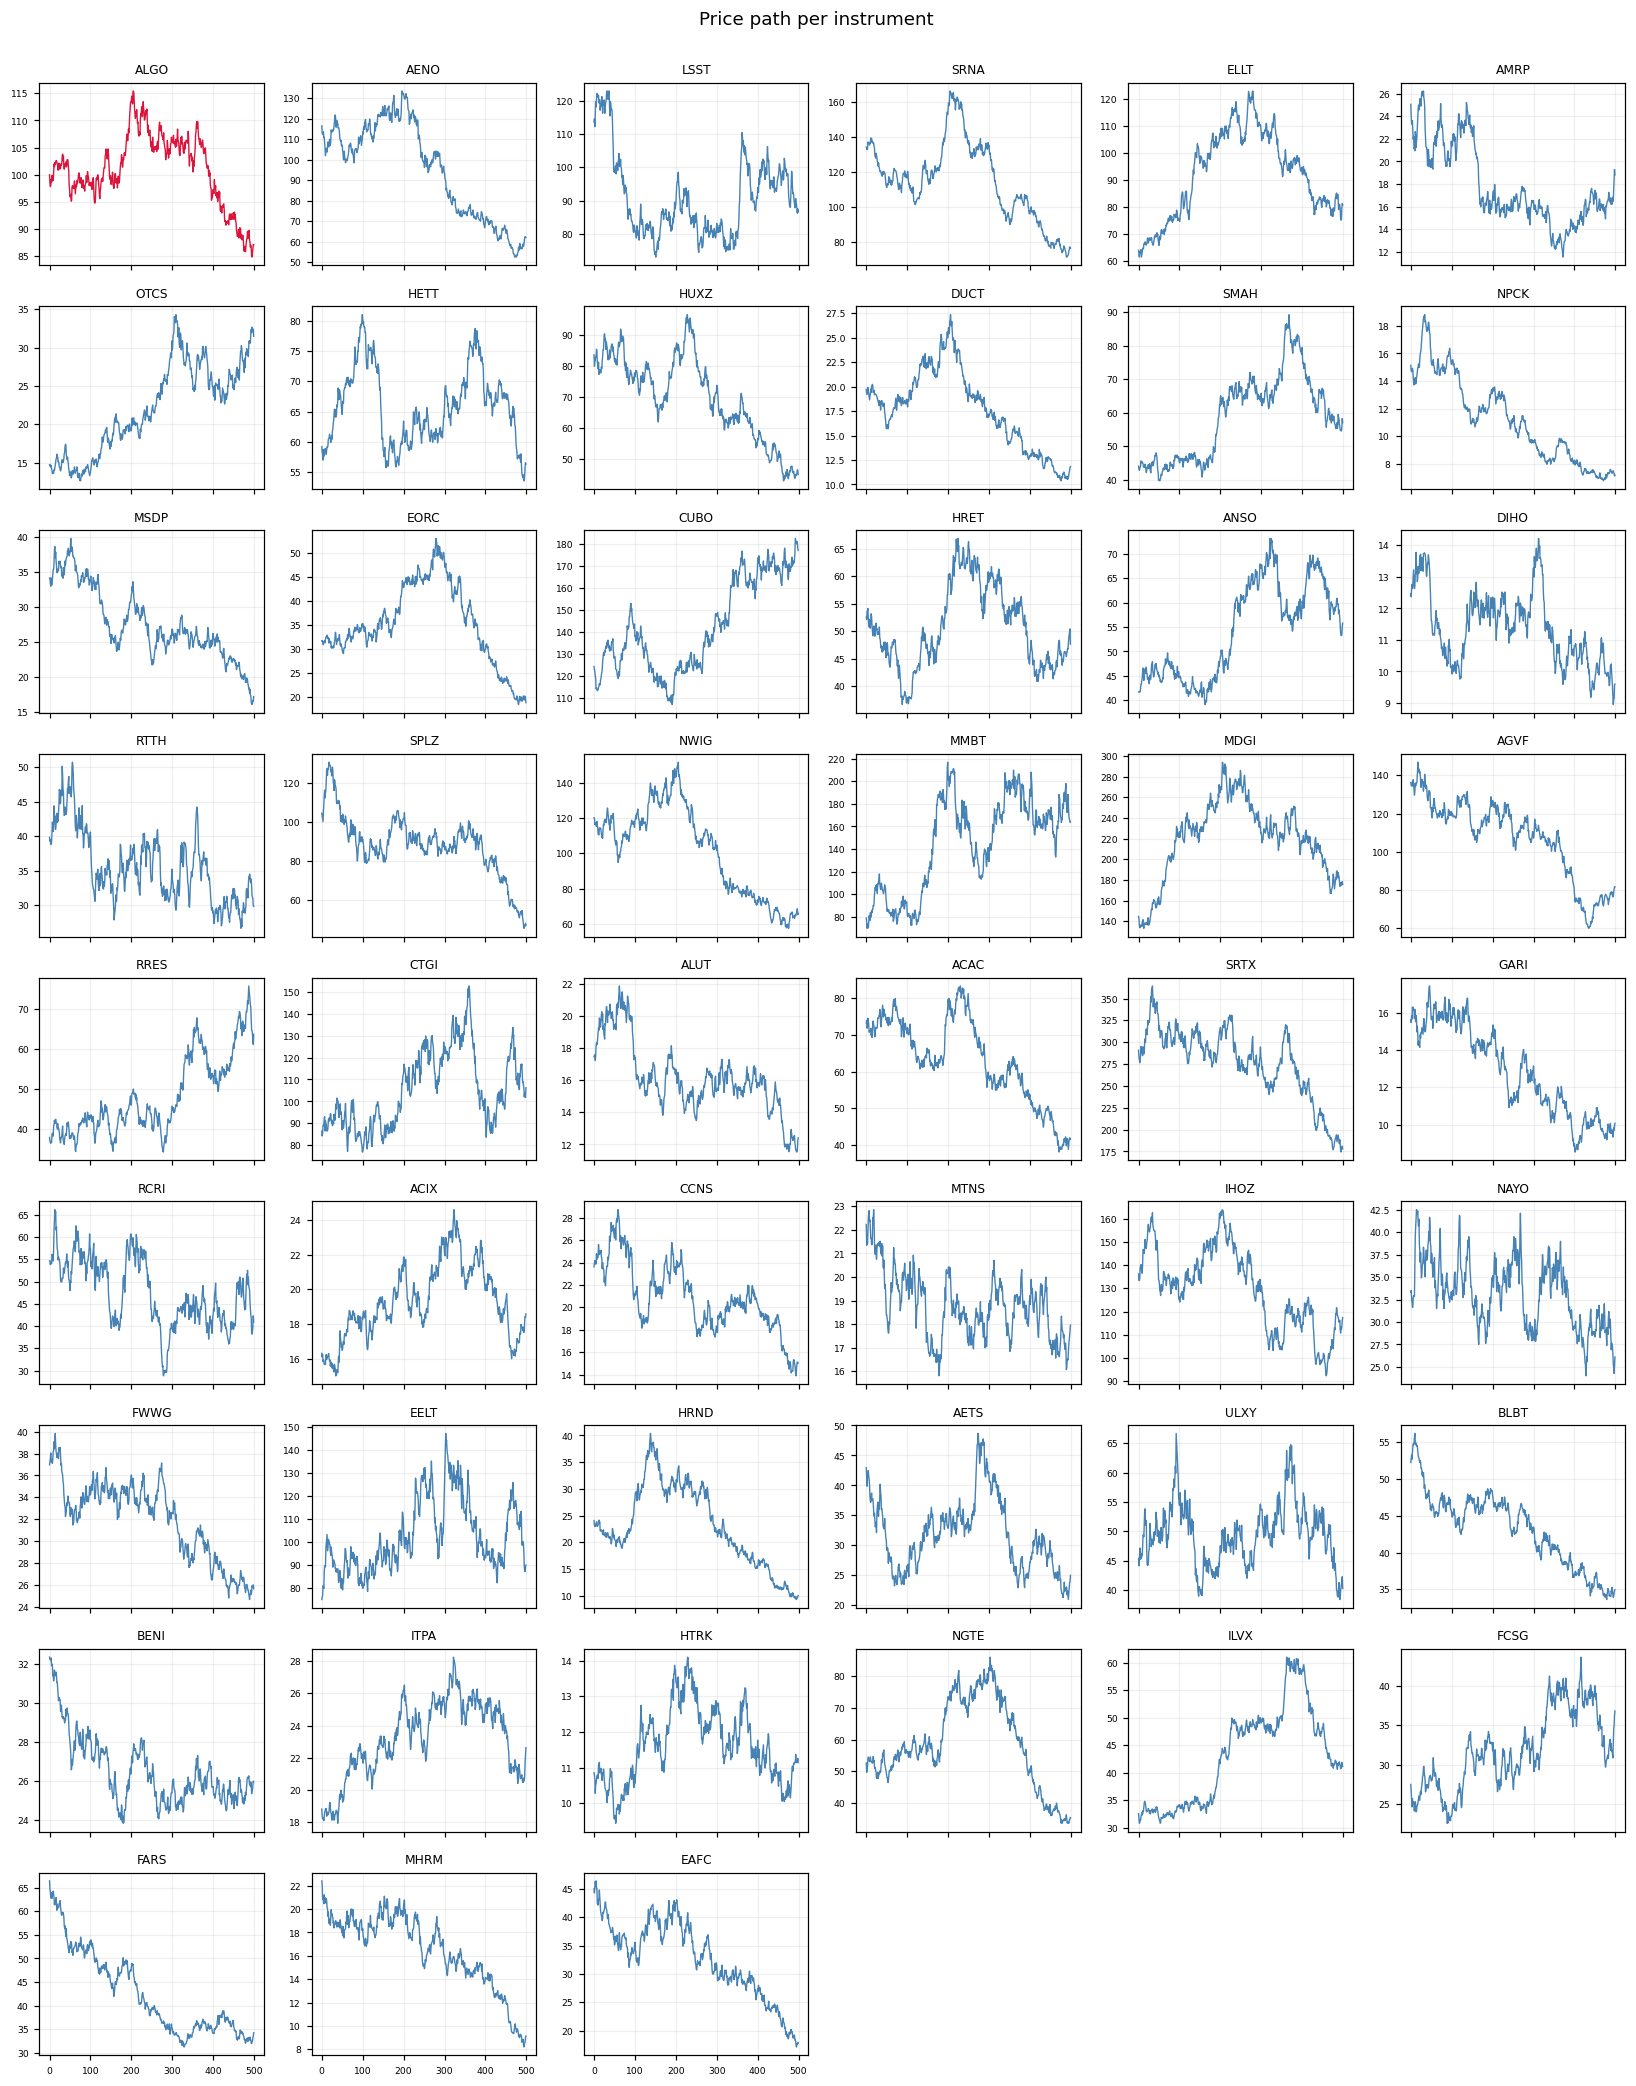

In [3]:
# Small multiples: every instrument on its own axis (spot regime shifts per name)
n = len(tickers); ncol = 6; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.1*nrow), sharex=True)
for i, tk in enumerate(tickers):
    ax = axes.flat[i]
    color = "crimson" if tk == "ALGO" else "steelblue"
    ax.plot(P[tk].values, color=color, lw=0.9)
    ax.set_title(tk, fontsize=8); ax.tick_params(labelsize=6); ax.grid(alpha=0.2)
for j in range(n, nrow*ncol): axes.flat[j].axis("off")
fig.suptitle("Price path per instrument", y=1.001); plt.tight_layout(); plt.show()

## 2. Returns & volatility

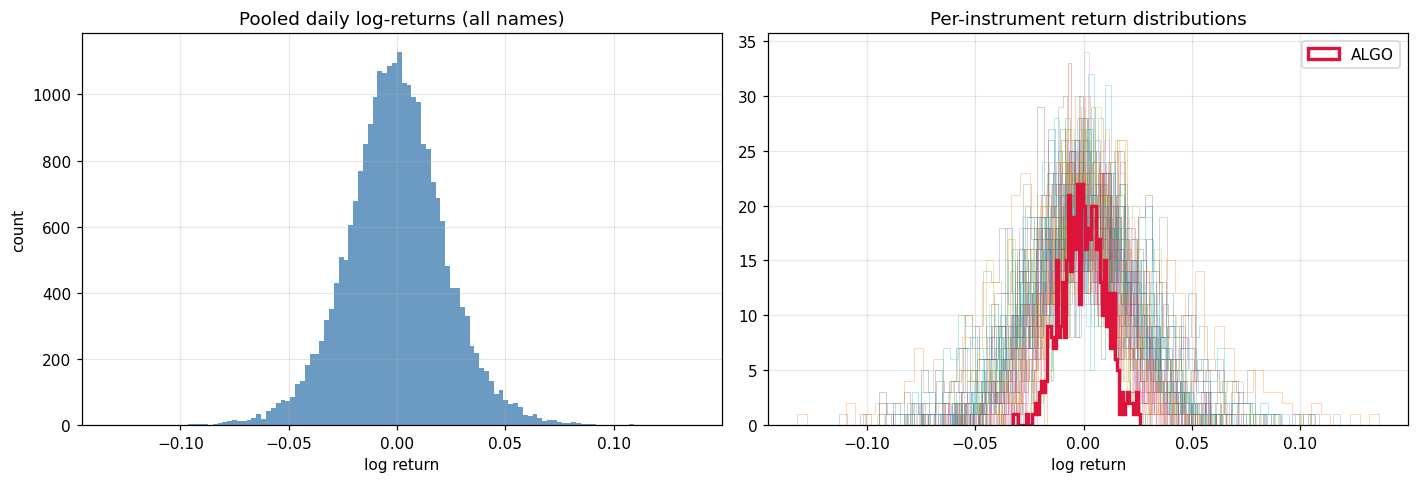

In [4]:
# Distribution of daily returns: overlaid density-ish view + ALGO
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(Rv.ravel(), bins=120, color="steelblue", alpha=0.8)
axes[0].set(title="Pooled daily log-returns (all names)", xlabel="log return", ylabel="count")
for tk in tickers:
    axes[1].hist(R[tk], bins=60, histtype="step", lw=0.5, alpha=0.4)
axes[1].hist(algo, bins=60, histtype="step", lw=2.2, color="crimson", label="ALGO")
axes[1].set(title="Per-instrument return distributions", xlabel="log return"); axes[1].legend()
plt.tight_layout(); plt.show()

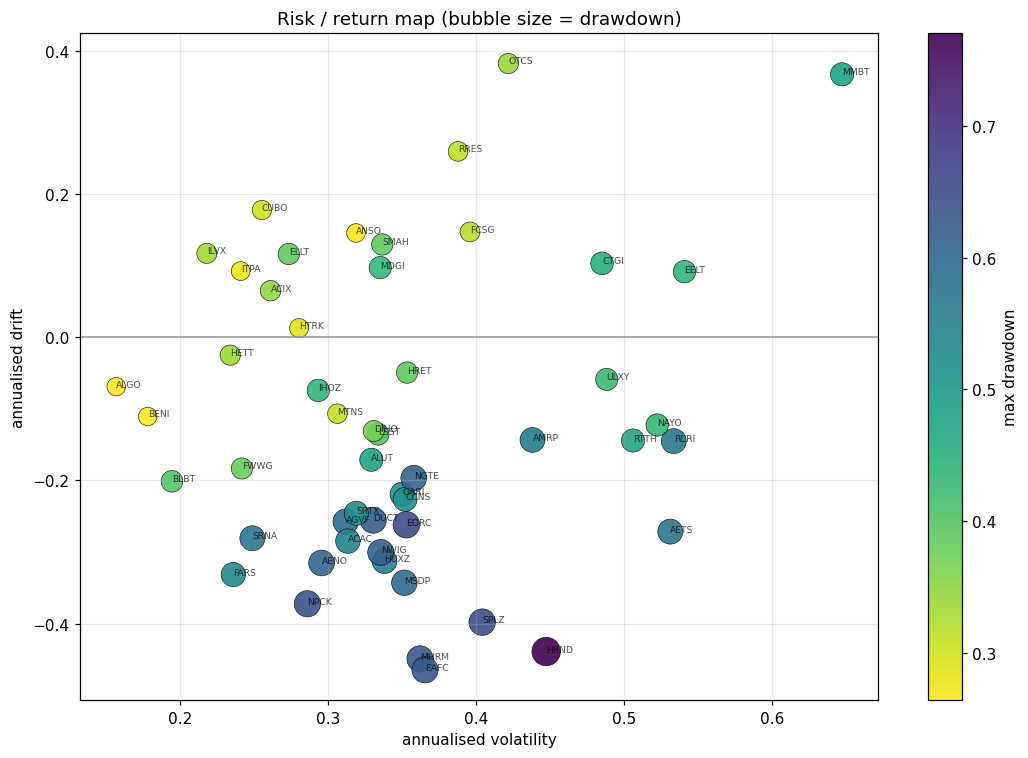

In [5]:
# Annualised return vs annualised vol — the risk/return map, sized by max drawdown
ann_ret = R.mean()*250
ann_vol = R.std()*np.sqrt(250)
maxdd = (1 - P/ P.cummax()).max()               # per-instrument max drawdown
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(ann_vol, ann_ret, s=40+400*maxdd, c=maxdd, cmap="viridis_r",
                edgecolor="k", lw=0.4, alpha=0.9)
for tk in tickers:
    ax.annotate(tk, (ann_vol[tk], ann_ret[tk]), fontsize=6, alpha=0.7)
ax.axhline(0, color="0.6", lw=1)
plt.colorbar(sc, label="max drawdown")
ax.set(title="Risk / return map (bubble size = drawdown)",
       xlabel="annualised volatility", ylabel="annualised drift")
plt.tight_layout(); plt.show()

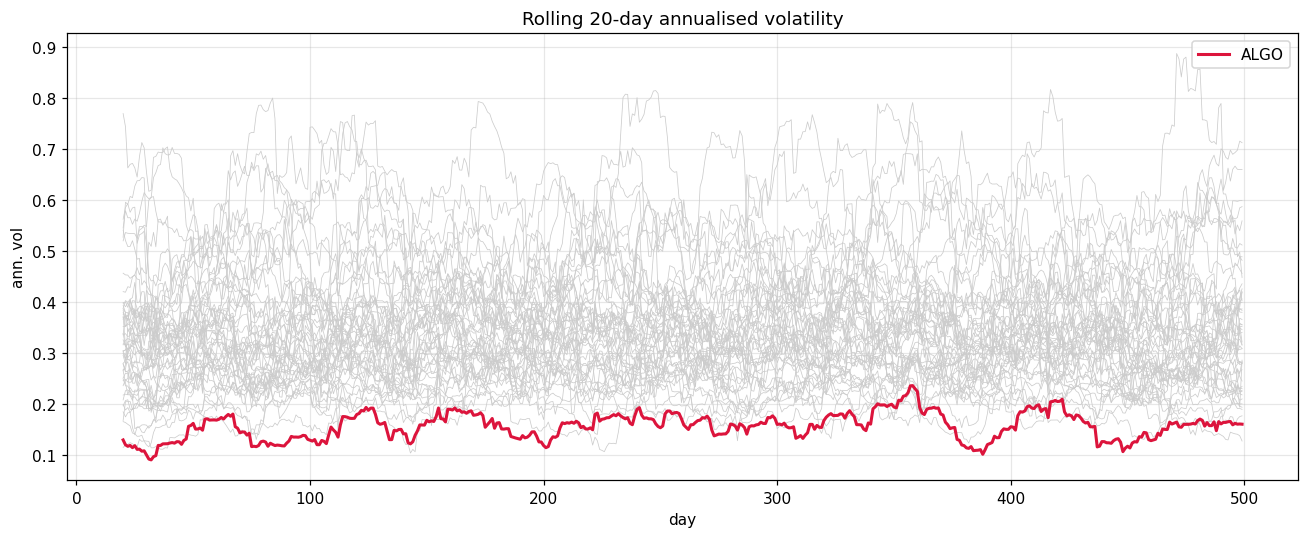

In [6]:
# Rolling 20-day annualised volatility for every instrument (grey) vs ALGO (red)
roll_vol = R.rolling(20).std()*np.sqrt(250)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(roll_vol.drop(columns="ALGO"), color="0.8", lw=0.5)
ax.plot(roll_vol["ALGO"], color="crimson", lw=2, label="ALGO")
ax.set(title="Rolling 20-day annualised volatility", xlabel="day", ylabel="ann. vol"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Cross-sectional structure (correlation & factors)

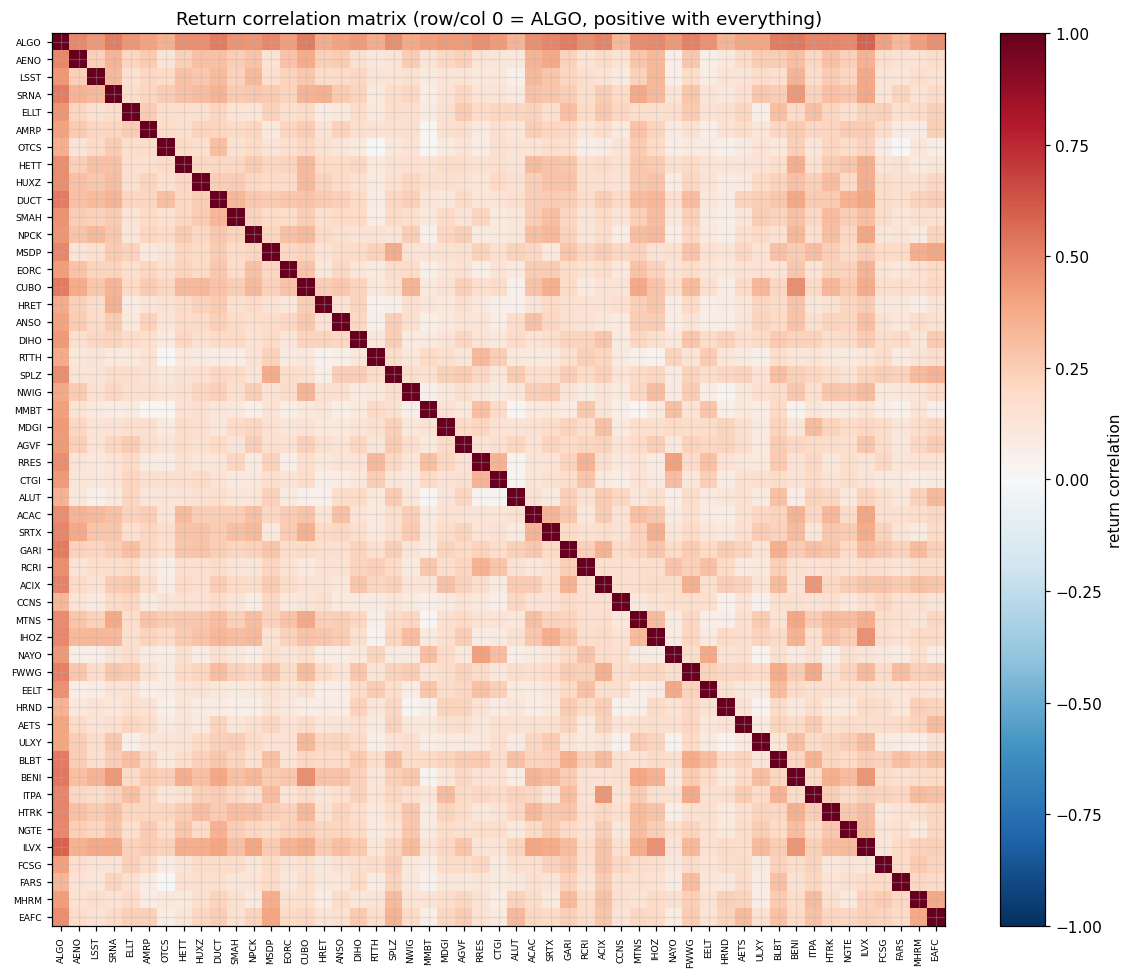

avg pairwise corr: 0.2


In [7]:
# Correlation heatmap with ticker labels
C = R.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers))); ax.set_xticklabels(tickers, rotation=90, fontsize=6)
ax.set_yticks(range(len(tickers))); ax.set_yticklabels(tickers, fontsize=6)
plt.colorbar(im, label="return correlation", fraction=0.046)
ax.set_title("Return correlation matrix (row/col 0 = ALGO, positive with everything)")
plt.tight_layout(); plt.show()
print("avg pairwise corr:", round(C.values[np.triu_indices(len(tickers),1)].mean(), 3))

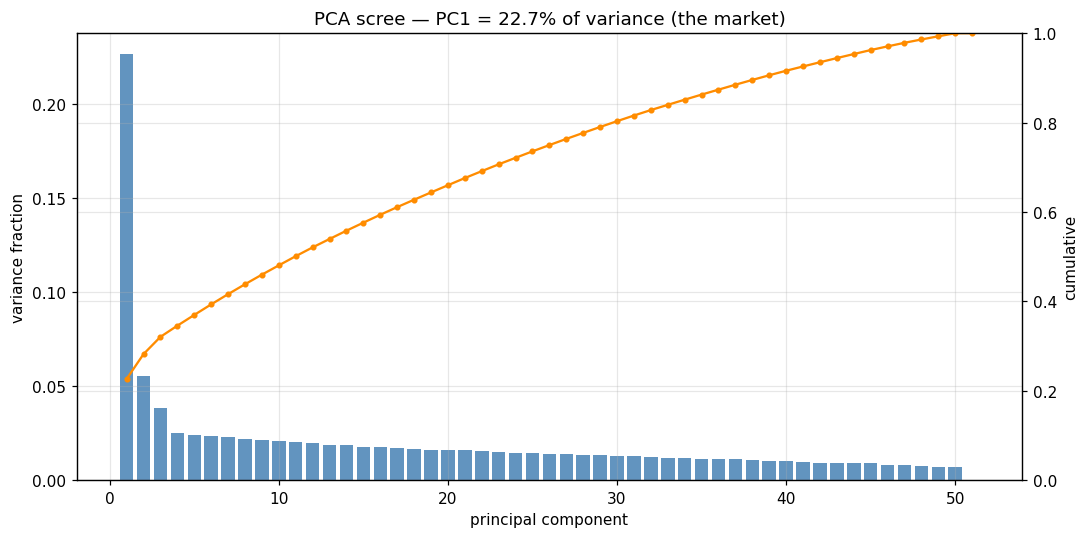

corr(ALGO, PC1): 0.986
corr(ALGO, equal-wt market): 0.993


In [8]:
# PCA via eigen-decomposition of the correlation matrix
eigval, eigvec = np.linalg.eigh(C.values)
eigval, eigvec = eigval[::-1], eigvec[:, ::-1]
N = len(eigval)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, N+1), eigval/N, color="steelblue", alpha=0.85)
ax1.set(xlabel="principal component", ylabel="variance fraction")
ax2 = ax1.twinx(); ax2.plot(range(1, N+1), np.cumsum(eigval)/N, color="darkorange", marker="o", ms=3)
ax2.set(ylabel="cumulative", ylim=(0, 1))
plt.title(f"PCA scree — PC1 = {eigval[0]/N:.1%} of variance (the market)")
plt.tight_layout(); plt.show()

# confirm ALGO IS the market factor
pc1 = Rv @ eigvec[:, 0]
print("corr(ALGO, PC1):", round(abs(np.corrcoef(algo, pc1)[0,1]), 3))
print("corr(ALGO, equal-wt market):", round(np.corrcoef(algo, Rv.mean(1))[0,1], 3))

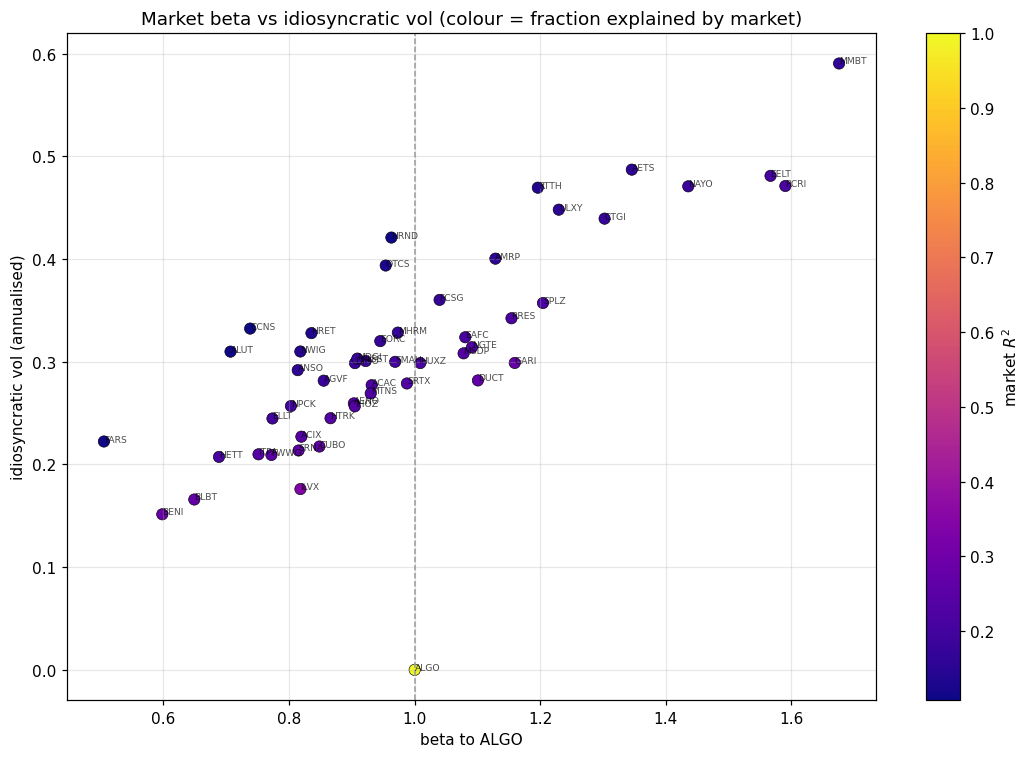

In [9]:
# Beta to ALGO and idiosyncratic vol for every instrument
a = algo.values; va = a.dot(a)
beta = (Rv.T @ a) / va
resid = Rv - np.outer(a, beta)
idio_vol = resid.std(0)*np.sqrt(250)
mkt_r2 = 1 - resid.var(0)/Rv.var(0)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(beta, idio_vol, c=mkt_r2, cmap="plasma", s=55, edgecolor="k", lw=0.4)
for i, tk in enumerate(tickers):
    ax.annotate(tk, (beta[i], idio_vol[i]), fontsize=6, alpha=0.7)
ax.axvline(1.0, color="0.6", ls="--", lw=1)
plt.colorbar(sc, label="market $R^2$")
ax.set(title="Market beta vs idiosyncratic vol (colour = fraction explained by market)",
       xlabel="beta to ALGO", ylabel="idiosyncratic vol (annualised)")
plt.tight_layout(); plt.show()

## 4. Per-instrument dashboard
Call `dashboard('TICKER')` for a full single-name view.

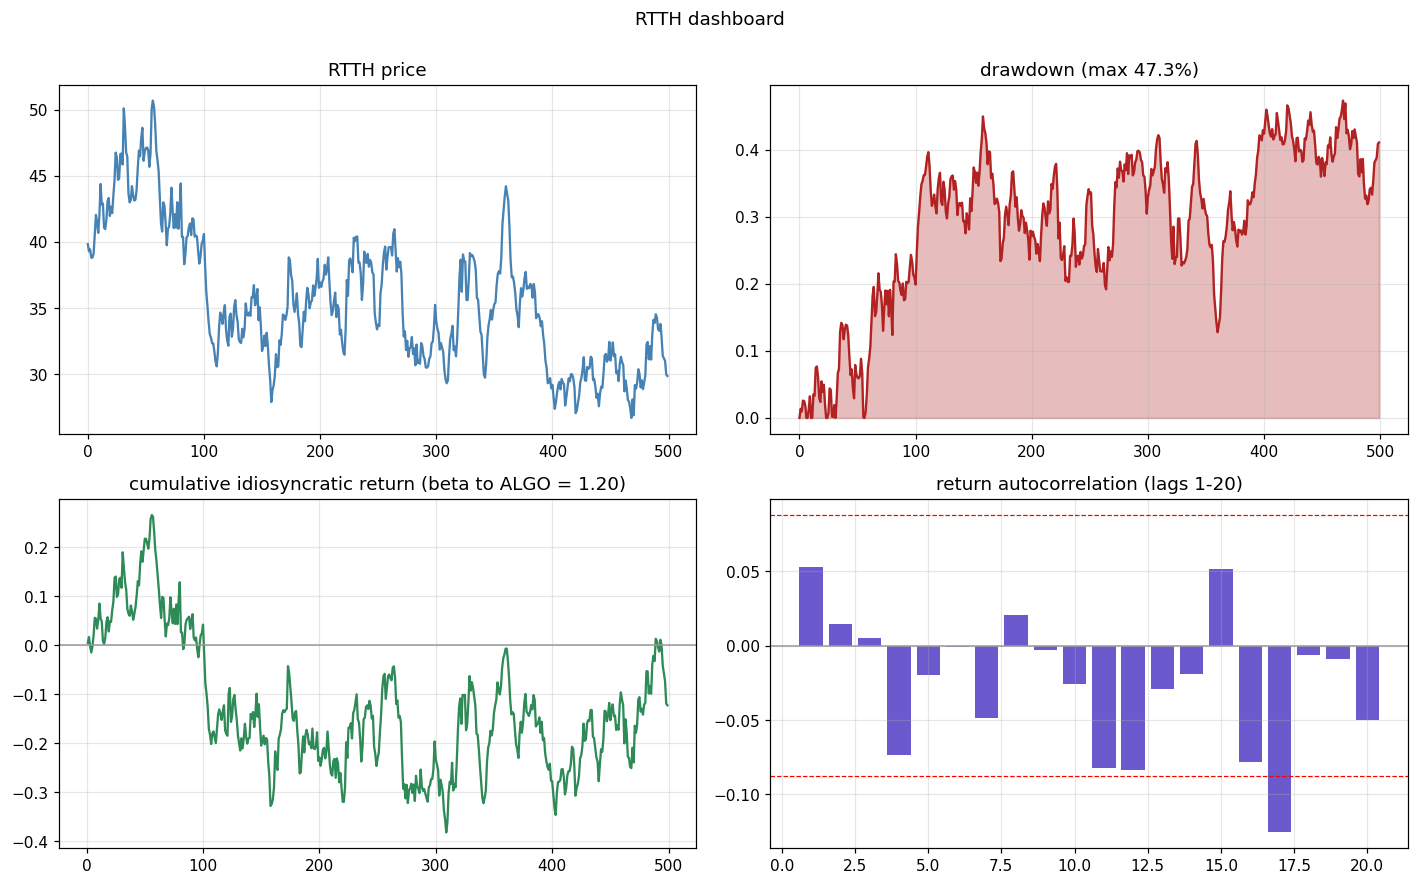

In [10]:
def dashboard(tk):
    px = P[tk]; r = R[tk]
    b = np.cov(r, algo)[0,1]/np.var(algo)
    res = r - b*algo
    dd = 1 - px/px.cummax()
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    ax[0,0].plot(px, color="steelblue"); ax[0,0].set_title(f"{tk} price")
    ax[0,1].plot(dd, color="firebrick"); ax[0,1].fill_between(range(len(dd)), dd, color="firebrick", alpha=0.3)
    ax[0,1].set_title(f"drawdown (max {dd.max():.1%})")
    ax[1,0].plot(res.cumsum(), color="seagreen"); ax[1,0].axhline(0, color="0.6", lw=1)
    ax[1,0].set_title(f"cumulative idiosyncratic return (beta to ALGO = {b:.2f})")
    lags = range(1, 21)
    acf = [r.autocorr(l) for l in lags]
    ax[1,1].bar(lags, acf, color="slateblue"); ax[1,1].axhline(0, color="0.6", lw=1)
    ax[1,1].axhline( 1.96/np.sqrt(len(r)), color="red", ls="--", lw=0.8)
    ax[1,1].axhline(-1.96/np.sqrt(len(r)), color="red", ls="--", lw=0.8)
    ax[1,1].set_title("return autocorrelation (lags 1-20)")
    plt.suptitle(f"{tk} dashboard", y=1.0); plt.tight_layout(); plt.show()

dashboard("RTTH")   # a strong residual mean-reverter

## 5. Interactive explorer (optional — needs `ipywidgets`)

In [11]:
try:
    from ipywidgets import interact, Dropdown
    interact(dashboard, tk=Dropdown(options=tickers, value="ALGO", description="ticker"))
except ImportError:
    print("ipywidgets not installed — run dashboard('TICKER') manually, e.g. dashboard('MMBT')")

interactive(children=(Dropdown(description='ticker', options=('ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', …

## 6. Summary table
One row per instrument with the headline stats; sort/filter as you like.

In [12]:
summary = pd.DataFrame({
    "ann_drift": (R.mean()*250).round(3),
    "ann_vol":   (R.std()*np.sqrt(250)).round(3),
    "total_ret_%": (100*(P.iloc[-1]/P.iloc[0]-1)).round(1),
    "beta":      pd.Series(beta, index=tickers).round(3),
    "mkt_R2":    pd.Series(mkt_r2, index=tickers).round(3),
    "idio_vol":  pd.Series(idio_vol, index=tickers).round(3),
    "max_dd_%":  (100*maxdd).round(1),
    "ac1":       R.apply(lambda s: s.autocorr(1)).round(3),
})
summary.sort_values("idio_vol", ascending=False)

,ann_drift,ann_vol,total_ret_%,beta,mkt_R2,idio_vol,max_dd_%,ac1
MMBT,0.367,0.647,108.1,1.676,0.166,0.590,47.8,0.011
AETS,-0.272,0.531,-41.8,1.346,0.158,0.487,56.9,-0.034
EELT,0.092,0.541,20.1,1.567,0.208,0.481,44.2,0.003
RCRI,-0.145,0.534,-25.1,1.590,0.219,0.471,56.4,0.064
NAYO,-0.123,0.522,-21.7,1.436,0.186,0.471,43.5,-0.007
RTTH,-0.144,0.506,-25.0,1.196,0.138,0.469,47.3,0.053
ULXY,-0.059,0.488,-11.1,1.229,0.156,0.448,42.5,-0.032
CTGI,0.103,0.485,22.9,1.302,0.178,0.439,45.2,0.014
HRND,-0.439,0.447,-58.4,0.963,0.113,0.421,77.0,-0.001
AMRP,-0.144,0.438,-24.9,1.129,0.163,0.400,56.0,0.057
